# Guided Numeric Exploration — AI & Data Science Job Salaries 2026
_Pay, remote work, AI-tool use, and automation fear in a synthetic 5,000-role panel_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [uditjain13/ai-and-data-science-job-salaries-2026](https://www.kaggle.com/datasets/uditjain13/ai-and-data-science-job-salaries-2026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Salary & Roles](#Univariate)** <br>
**4. [Experience, Remote, Geography](#Structure)** <br>
**5. [Salary by Title × Experience](#TitleExp)** <br>
**6. [Location & Salary Deep Dive](#Location)** <br>
**7. [AI Tools, Satisfaction, Automation Fear](#AITools)** <br>
**8. [Education, Titles, Fear](#EduTitles)** <br>
**9. [Multivariate Association](#Association)** <br>
**10. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** 5,000×27 table of AI/data roles built for modeling practice (CC0). Beyond classic salary fields it includes daily AI-tool use, AI hours, certifications, equity/bonus, satisfaction, and a self-reported `fears_ai_automation_score`.

I treat associations as properties of the generator, not real employer pay bands. When sketching salary predictors I exclude equity/bonus as leakage-adjacent compensation components.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "ai_ds_job_salaries_2026.csv"
KAGGLE_SLUG = "uditjain13/ai-and-data-science-job-salaries-2026"
EXPECTED_COLS = [
    "job_title", "experience_level", "employment_type", "company_size", "company_location",
    "employee_residence", "industry", "remote_ratio", "years_experience", "education_level",
    "primary_language", "has_ml_in_title", "manages_people", "team_size", "certifications_count",
    "weekly_hours", "uses_ai_tools_daily", "ai_tools_hours_per_week", "salary_currency", "salary_usd",
    "equity_offered_pct", "bonus_pct", "job_satisfaction_score", "interviews_to_offer",
    "switched_jobs_last_year", "upskilling_hours_per_month", "fears_ai_automation_score",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    if not p.exists():
        hits = list(root.rglob(CSV_BASENAME))
        assert hits, f"expected {CSV_BASENAME} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 5000, f"expected 5000 rows, got {len(df)}"
assert df.isnull().sum().sum() == 0, "card claims zero nulls"
assert (df["salary_usd"] > 0).all()

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("salary_usd mean/median:", round(df["salary_usd"].mean()), round(df["salary_usd"].median()))


Missing Values: 0
Dataframe Dimension: 5000 Rows, 27 Columns
salary_usd mean/median: 98605 90572


**Code Explanation and Reasoning:** <br>
Schema and the zero-null claim are asserted. This is synthetic practice data — useful for pattern discovery and modeling drills, not for quoting real 2026 offers.


In [3]:
df.sample(5, random_state=7)


,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
3406,Research Scientist,Senior,Full-time,M,AU,AU,Retail,100,11.3,Masters,SQL,True,False,4,2,39.1,True,11.7,AUD,150998,0.075,3.4,7.2,5,False,6.6,3.0
757,LLM Engineer,Mid,Freelance,M,IN,IN,Technology,50,8.7,Bootcamp,SQL,True,False,10,2,45.1,True,7.5,INR,31528,0.200,15.1,5.8,5,True,14.2,4.1
3624,MLOps Engineer,Entry,Contract,M,US,US,Energy,100,1.7,Masters,Python,False,False,10,5,40.0,True,10.0,USD,68910,0.125,2.1,7.0,5,False,12.7,7.7
4544,Data Scientist,Senior,Full-time,L,US,US,Technology,50,10.4,Bachelors,Python,False,False,7,0,46.7,True,13.0,USD,176945,0.000,9.3,6.4,5,False,1.0,1.0
3235,Business Intelligence Analyst,Senior,Full-time,M,US,US,Education,100,11.7,PhD,Python,False,True,5,1,39.2,True,9.9,USD,116251,0.029,12.1,7.8,6,False,6.8,7.7


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False).head(20))
df[["salary_usd", "years_experience", "ai_tools_hours_per_week", "fears_ai_automation_score", "job_satisfaction_score"]].describe().T.round(2)


,Column,Unique,Null
19,salary_usd,4928,0
20,equity_offered_pct,684,0
15,weekly_hours,344,0
21,bonus_pct,258,0
17,ai_tools_hours_per_week,240,0
8,years_experience,230,0
25,upskilling_hours_per_month,217,0
26,fears_ai_automation_score,91,0
22,job_satisfaction_score,80,0
13,team_size,19,0


,count,mean,std,min,25%,50%,75%,max
salary_usd,5000.0,98605.41,55369.31,12000.0,55592.75,90572.0,129657.75,372347.0
years_experience,5000.0,8.36,4.82,0.0,4.80,8.1,11.50,23.7
ai_tools_hours_per_week,5000.0,8.44,5.50,0.0,3.30,8.5,12.62,25.2
fears_ai_automation_score,5000.0,4.85,1.73,1.0,3.70,4.8,6.00,10.0
job_satisfaction_score,5000.0,6.69,1.36,1.1,5.80,6.7,7.60,10.0


**Interpretation** <br>
Salary is continuous and right-skewed. Experience level, title, location, and remote ratio are the usual structural axes; AI-tool and fear scores are the distinctive 2026-era fields.


# **3. Univariate Salary & Roles:** <a id="Univariate"></a>


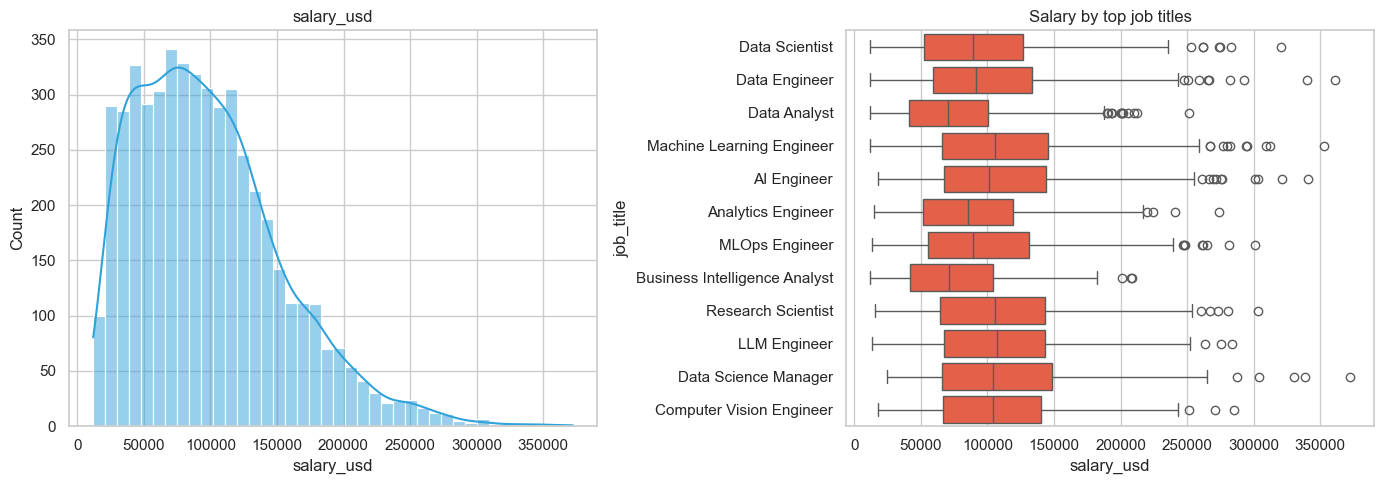

,n
job_title,
Data Scientist,709
Data Engineer,682
Data Analyst,627
Machine Learning Engineer,593
AI Engineer,506
Analytics Engineer,317
MLOps Engineer,306
Business Intelligence Analyst,293
Research Scientist,269


In [5]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["salary_usd"], bins=40, kde=True, ax=ax[0], color="#30a2da")
ax[0].set_title("salary_usd")
top_titles = df["job_title"].value_counts().head(12).index
sns.boxplot(
    data=df[df["job_title"].isin(top_titles)],
    y="job_title", x="salary_usd", order=top_titles, ax=ax[1], color="#fc4f30",
)
ax[1].set_title("Salary by top job titles")
plt.tight_layout()
plt.show()
display(df["job_title"].value_counts().head(12).to_frame("n"))


**How to Interpret:** <br>
Title boxes show which role labels the generator pays up. Overlap across titles means title alone is a noisy salary signal once seniority and market enter.


# **4. Experience, Remote, Geography:** <a id="Structure"></a>


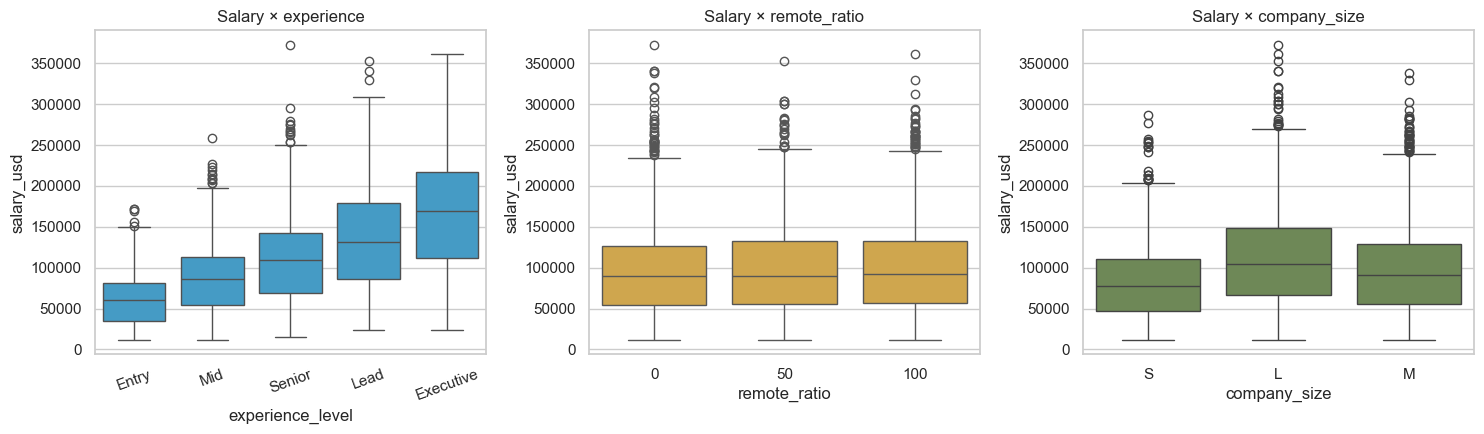

In [6]:
exp_order = ["Entry", "Mid", "Senior", "Lead", "Executive"]
exp_order = [e for e in exp_order if e in set(df["experience_level"])]
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="experience_level", y="salary_usd", order=exp_order, ax=ax[0], color="#30a2da")
ax[0].set_title("Salary × experience")
ax[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=df, x="remote_ratio", y="salary_usd", ax=ax[1], color="#e5ae38")
ax[1].set_title("Salary × remote_ratio")
sns.boxplot(data=df, x="company_size", y="salary_usd", ax=ax[2], color="#6d904f")
ax[2].set_title("Salary × company_size")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Experience should dominate if the generator is well-behaved. Remote ratio premium/discount and company-size gaps are the next structural questions. Geography is deferred to the location deep dive below — raw location medians without experience/title controls are easy to misread.


# **5. Salary by Title × Experience:** <a id="TitleExp"></a>


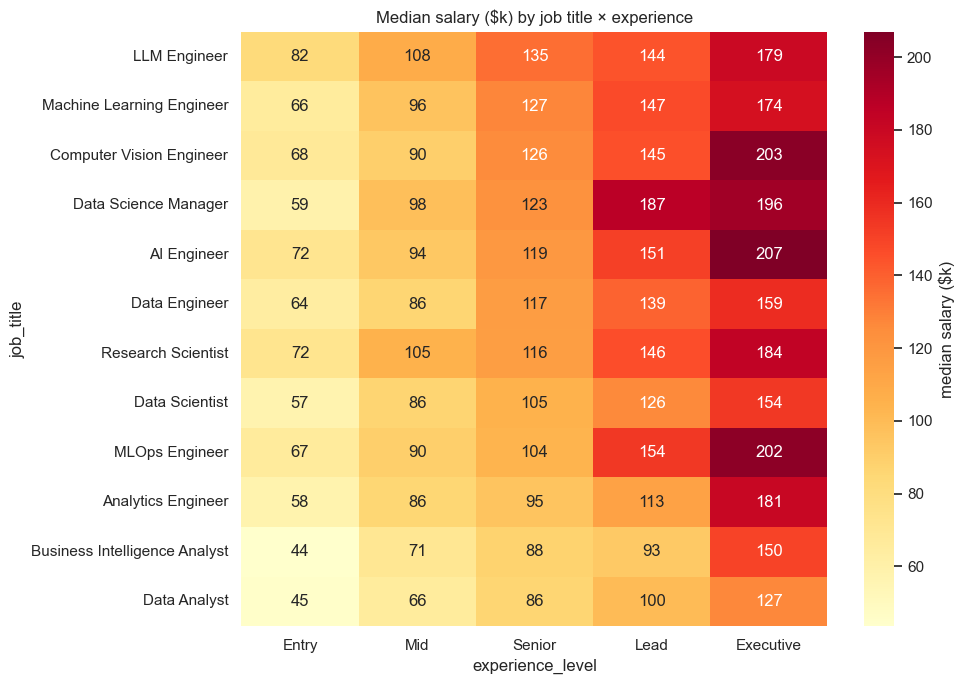

experience_level,Entry,Mid,Senior,Lead,Executive
job_title,,,,,
LLM Engineer,81994.0,108383.0,134870.0,143807.0,179298.0
Machine Learning Engineer,65886.0,96177.0,127308.0,147338.0,173856.0
Computer Vision Engineer,67945.0,89724.0,125708.0,145128.0,203383.0
Data Science Manager,58758.0,98347.0,122715.0,186766.0,195824.0
AI Engineer,71776.0,93864.0,119421.0,151176.0,206967.0
Data Engineer,63995.0,86029.0,116623.0,139305.0,158750.0
Research Scientist,72337.0,104878.0,116269.0,146254.0,184320.0
Data Scientist,57000.0,86438.0,104993.0,125983.0,154355.0
MLOps Engineer,66514.0,89578.0,103845.0,154441.0,201867.0


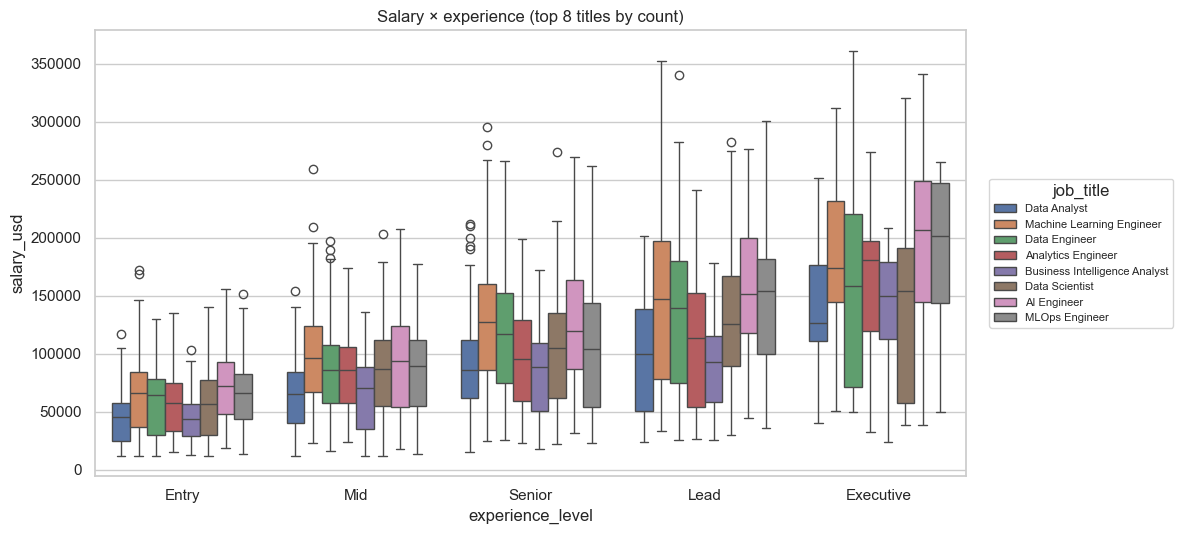

experience_level,Entry,Mid,Senior,Lead,Executive
title rank within experience (1=highest median),,,,,
LLM Engineer,1,1,1,7,7
Machine Learning Engineer,6,4,2,4,8
Computer Vision Engineer,4,6,3,6,2
Data Science Manager,8,3,4,1,4
AI Engineer,3,5,5,3,1
Data Engineer,7,9,6,8,9
Research Scientist,2,2,7,5,5
Data Scientist,10,8,8,9,10
MLOps Engineer,5,7,9,2,3


In [7]:
# Median salary heatmap: job_title × experience_level
title_exp_med = (
    df.groupby(["job_title", "experience_level"])["salary_usd"]
    .median()
    .unstack()
    .reindex(columns=exp_order)
)
# Order titles by Senior median (stable middle band)
title_order_pay = title_exp_med["Senior"].sort_values(ascending=False).index
title_exp_med = title_exp_med.reindex(title_order_pay)

f, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    title_exp_med / 1000,
    annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "median salary ($k)"},
)
ax.set_title("Median salary ($k) by job title × experience")
ax.set_xlabel("experience_level")
ax.set_ylabel("job_title")
plt.tight_layout()
plt.show()
display(title_exp_med.round(0))

# Same slice as boxplots for the top titles by volume
top_titles_n = df["job_title"].value_counts().head(8).index
f, ax = plt.subplots(figsize=(12, 5.5))
sns.boxplot(
    data=df[df["job_title"].isin(top_titles_n)],
    x="experience_level", y="salary_usd",
    hue="job_title", order=exp_order, ax=ax,
)
ax.set_title("Salary × experience (top 8 titles by count)")
ax.legend(title="job_title", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
plt.tight_layout()
plt.show()

# Title rank stability: which titles stay high across seniority
rank_by_exp = title_exp_med.rank(ascending=False, method="min")
display(rank_by_exp.astype(int).rename_axis("title rank within experience (1=highest median)"))


**How to Interpret:** <br>
The heatmap holds experience fixed while comparing titles — the right way to read title premiums in this panel. Boxplots for high-volume titles show spread, not just medians. Rank tables ask whether a title’s relative standing is stable from Entry through Executive (or whether some labels only pay well at senior levels).


# **6. Location & Salary Deep Dive:** <a id="Location"></a>


,median,mean,n,vs_US
company_location,,,,
US,126987.0,135662.0,1786,1.000
CA,101216.0,107261.0,350,0.797
AU,100133.0,108565.0,240,0.789
GB,95321.0,100562.0,488,0.751
NL,94470.0,102304.0,200,0.744
DE,89107.0,96419.0,350,0.702
SG,88195.0,94550.0,130,0.695
FR,78405.0,85178.0,189,0.617
ES,71346.0,73861.0,128,0.562


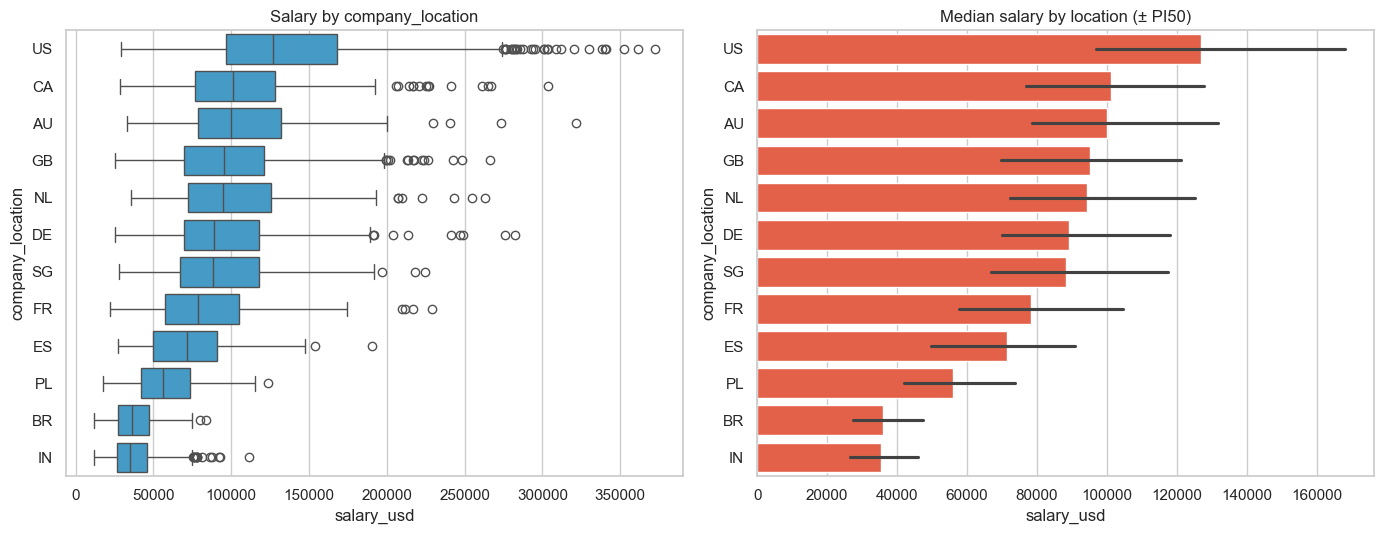

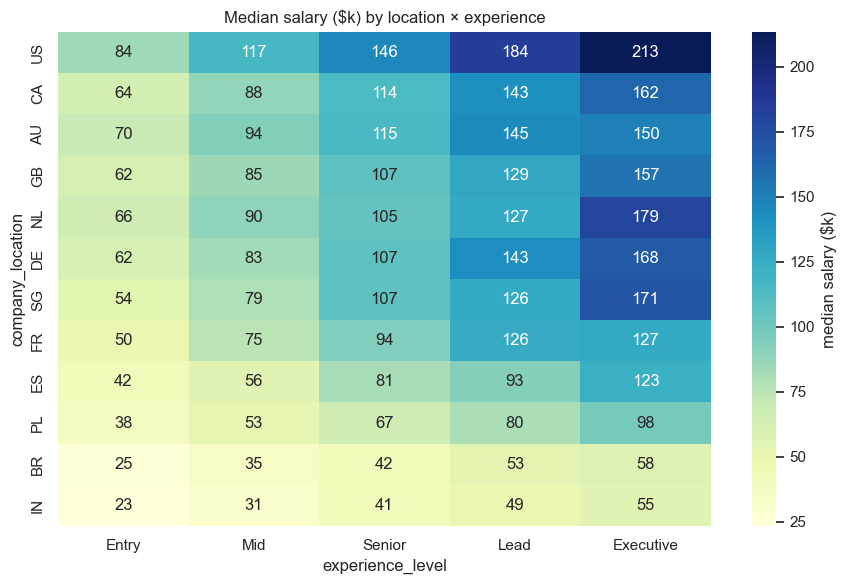

experience_level,Entry,Mid,Senior,Lead,Executive
company_location,,,,,
US,84371.0,116508.0,146433.0,183769.0,213378.0
CA,63503.0,88302.0,114254.0,142640.0,162068.0
AU,70117.0,93722.0,114802.0,144800.0,149578.0
GB,62236.0,85082.0,107195.0,128652.0,156505.0
NL,66473.0,89974.0,104742.0,126934.0,179294.0
DE,61846.0,83006.0,106918.0,143496.0,167683.0
SG,54474.0,79489.0,106910.0,125972.0,170566.0
FR,49685.0,74901.0,94290.0,125755.0,127109.0
ES,41946.0,56010.0,81326.0,92707.0,122647.0


experience_level,Entry,Mid,Senior,Lead,Executive
experience mix (row %),,,,,
US,0.194,0.325,0.312,0.124,0.045
CA,0.180,0.326,0.309,0.117,0.069
AU,0.175,0.346,0.296,0.133,0.050
GB,0.180,0.328,0.293,0.150,0.049
NL,0.175,0.290,0.295,0.185,0.055
DE,0.206,0.357,0.286,0.120,0.031
SG,0.185,0.346,0.254,0.154,0.062
FR,0.228,0.317,0.307,0.122,0.026
ES,0.180,0.266,0.336,0.164,0.055


,resid_mean,resid_median,n
company_location,,,
US,37412.0,32773.0,1786
CA,6475.0,4695.0,350
AU,9713.0,6969.0,240
GB,547.0,-904.0,488
NL,-1877.0,-4327.0,200
DE,-550.0,-2668.0,350
SG,-7197.0,-7661.0,130
FR,-11520.0,-13035.0,189
ES,-27963.0,-28754.0,128


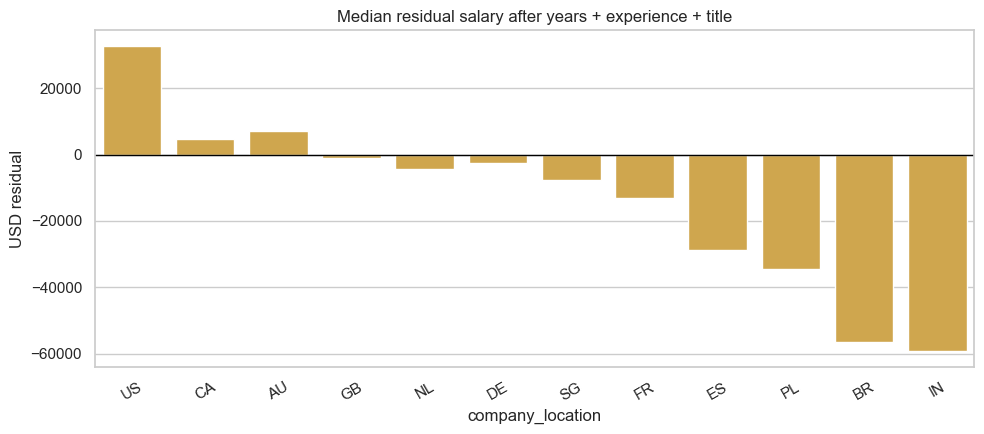

Linear R² (years + experience + title): 0.301
Linear R² (+ company_location): 0.718
Share company_location == employee_residence: 0.9


,median,mean,count
loc_match,,,
False,89403.0,95711.0,501
True,90816.0,98928.0,4499


Cross-border n: 501


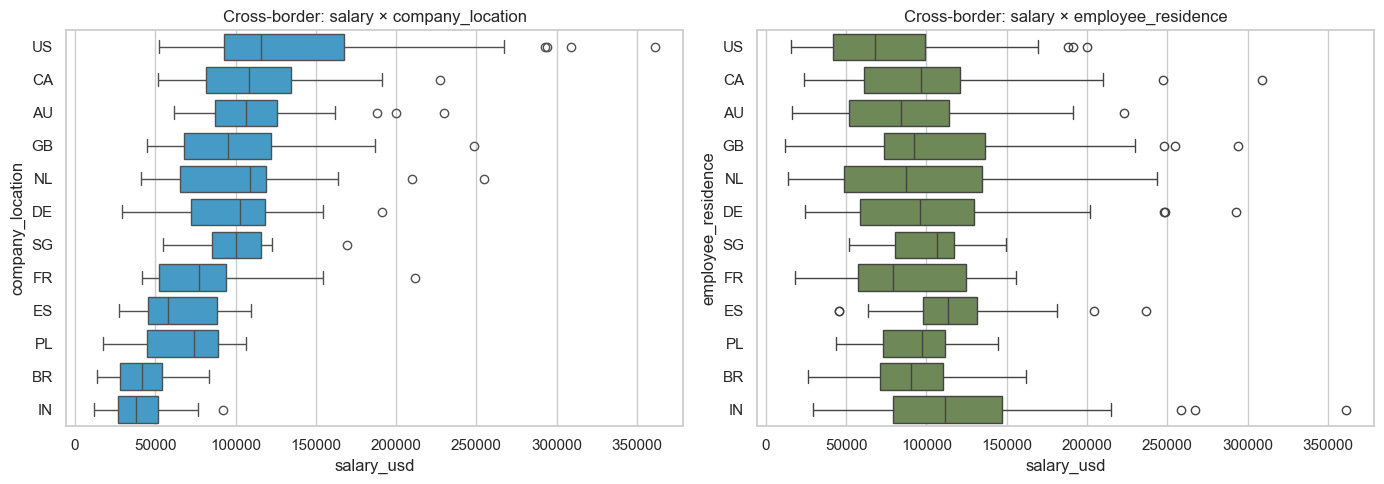

,remote_mean,salary_median,n
company_location,,,
US,42.0,126987.0,1786
CA,43.3,101215.5,350
AU,41.9,100133.0,240
GB,44.9,95321.0,488
NL,47.8,94470.0,200
DE,42.0,89107.0,350
SG,47.7,88195.0,130
FR,43.9,78405.0,189
ES,42.6,71346.5,128


In [8]:
# --- Raw geography: company_location pay ladder ---
loc_order = (
    df.groupby("company_location")["salary_usd"]
    .median()
    .sort_values(ascending=False)
    .index
)
loc_pay = (
    df.groupby("company_location")["salary_usd"]
    .agg(median="median", mean="mean", n="count")
    .reindex(loc_order)
    .round(0)
)
us_med = loc_pay.loc["US", "median"]
loc_pay["vs_US"] = (loc_pay["median"] / us_med).round(3)
display(loc_pay)

f, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(
    data=df, y="company_location", x="salary_usd",
    order=loc_order, ax=ax[0], color="#30a2da",
)
ax[0].set_title("Salary by company_location")
sns.barplot(
    data=df, y="company_location", x="salary_usd",
    order=loc_order, ax=ax[1], color="#fc4f30",
    estimator="median", errorbar=("pi", 50),
)
ax[1].set_title("Median salary by location (± PI50)")
plt.tight_layout()
plt.show()

# --- Does location survive experience controls? ---
loc_exp = (
    df.groupby(["company_location", "experience_level"])["salary_usd"]
    .median()
    .unstack()
    .reindex(index=loc_order, columns=exp_order)
)
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    loc_exp / 1000,
    annot=True, fmt=".0f", cmap="YlGnBu", ax=ax,
    cbar_kws={"label": "median salary ($k)"},
)
ax.set_title("Median salary ($k) by location × experience")
plt.tight_layout()
plt.show()
display(loc_exp.round(0))

# Experience mix is similar across markets — location is not just seniority composition
exp_mix = (
    pd.crosstab(df["company_location"], df["experience_level"], normalize="index")
    .reindex(index=loc_order, columns=exp_order)
    .round(3)
)
display(exp_mix.rename_axis("experience mix (row %)"))

# --- Residual location premium after years + experience + title ---
from sklearn.linear_model import LinearRegression

struct_num = ["years_experience"]
struct_cat = ["experience_level", "job_title"]
X_struct = df[struct_num + struct_cat]
y_sal = df["salary_usd"]
pre_struct = ColumnTransformer(
    [
        ("num", "passthrough", struct_num),
        ("cat", OneHotEncoder(drop="first"), struct_cat),
    ]
)
pipe_struct = Pipeline([
    ("pre", pre_struct),
    ("lr", LinearRegression()),
])
pipe_struct.fit(X_struct, y_sal)
resid = y_sal - pipe_struct.predict(X_struct)
resid_by_loc = (
    resid.groupby(df["company_location"])
    .agg(resid_mean="mean", resid_median="median", n="count")
    .reindex(loc_order)
    .round(0)
)
display(resid_by_loc)

f, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(
    x=resid_by_loc.index, y=resid_by_loc["resid_median"],
    ax=ax, color="#e5ae38",
)
ax.axhline(0, color="black", lw=1)
ax.set_title("Median residual salary after years + experience + title")
ax.set_ylabel("USD residual")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# R² lift when company_location is added
X_loc = df[struct_num + struct_cat + ["company_location"]]
pre_loc = ColumnTransformer(
    [
        ("num", "passthrough", struct_num),
        ("cat", OneHotEncoder(drop="first"), struct_cat + ["company_location"]),
    ]
)
pipe_loc = Pipeline([("pre", pre_loc), ("lr", LinearRegression())])
pipe_loc.fit(X_loc, y_sal)
print(
    "Linear R² (years + experience + title):",
    round(pipe_struct.score(X_struct, y_sal), 3),
)
print(
    "Linear R² (+ company_location):",
    round(pipe_loc.score(X_loc, y_sal), 3),
)

# --- Company location vs employee residence ---
df["loc_match"] = df["company_location"] == df["employee_residence"]
print("Share company_location == employee_residence:", round(df["loc_match"].mean(), 3))
display(
    df.groupby("loc_match")["salary_usd"]
    .agg(["median", "mean", "count"])
    .round(0)
)

# Cross-border: still tracks company_location more than residence
cross = df[~df["loc_match"]].copy()
print("Cross-border n:", len(cross))
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=cross, y="company_location", x="salary_usd",
    order=[c for c in loc_order if c in set(cross["company_location"])],
    ax=ax[0], color="#30a2da",
)
ax[0].set_title("Cross-border: salary × company_location")
sns.boxplot(
    data=cross, y="employee_residence", x="salary_usd",
    order=[c for c in loc_order if c in set(cross["employee_residence"])],
    ax=ax[1], color="#6d904f",
)
ax[1].set_title("Cross-border: salary × employee_residence")
plt.tight_layout()
plt.show()

# Location × remote (is the geo gap a remote-mix artifact?)
remote_by_loc = (
    df.groupby("company_location")
    .agg(
        remote_mean=("remote_ratio", "mean"),
        salary_median=("salary_usd", "median"),
        n=("salary_usd", "count"),
    )
    .reindex(loc_order)
    .round(1)
)
display(remote_by_loc)


**How to Interpret:** <br>
Raw medians show a steep ladder (US ≈ 3.6× India in this generator). The location × experience heatmap and experience-mix table check whether that gap is just seniority composition — here mixes are similar, so geography is not a proxy for “more seniors in the US.” Residual bars after years + experience + title are the cleaner location premium; the R² jump when `company_location` is added quantifies how much unique pay signal location carries. Cross-border rows (~10%) still track company location more than residence. Mean remote ratio barely differs by country, so remote mix does not explain the geo gap.


# **7. AI Tools, Satisfaction, Automation Fear:** <a id="AITools"></a>


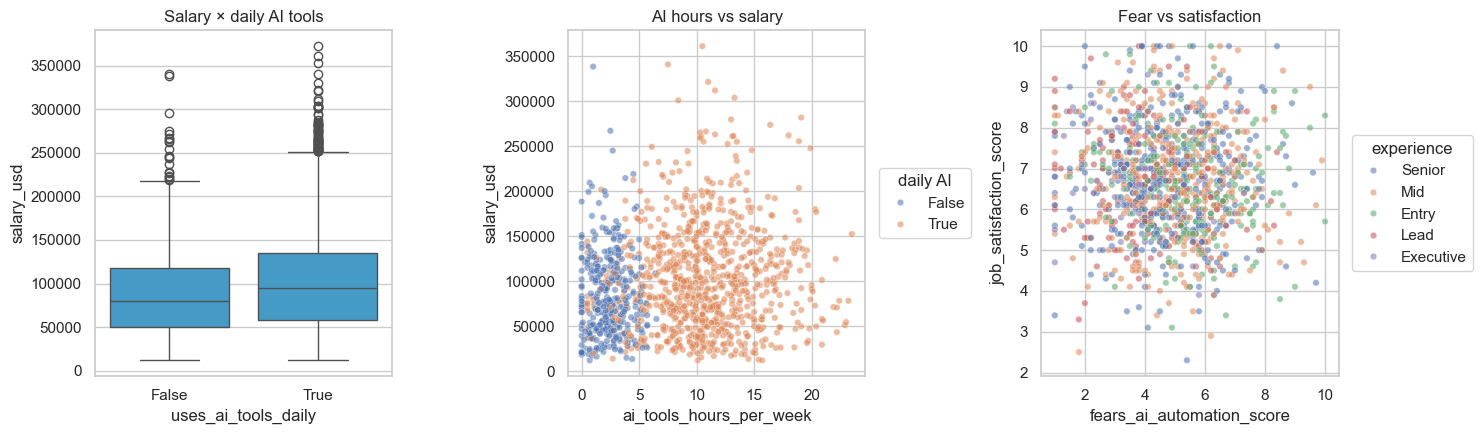

experience_level,Entry,Mid,Senior,Lead,Executive
title_family,,,,,
AI/ML-family,68104.0,94386.0,122637.0,147028.0,199252.0
Other DS/Analytics,53900.0,79792.0,101715.0,123762.0,154542.0


In [9]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="uses_ai_tools_daily", y="salary_usd", ax=ax[0], color="#30a2da")
ax[0].set_title("Salary × daily AI tools")
sns.scatterplot(
    data=df.sample(1200, random_state=7),
    x="ai_tools_hours_per_week", y="salary_usd",
    hue="uses_ai_tools_daily", ax=ax[1], alpha=0.55, s=22,
)
ax[1].set_title("AI hours vs salary")
ax[1].legend(title="daily AI", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.scatterplot(
    data=df.sample(1200, random_state=7),
    x="fears_ai_automation_score", y="job_satisfaction_score",
    hue="experience_level", ax=ax[2], alpha=0.55, s=22,
)
ax[2].set_title("Fear vs satisfaction")
ax[2].legend(title="experience", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Title family: AI/LLM vs classic DS
df["title_family"] = np.where(
    df["job_title"].str.contains("AI|LLM|MLOps|Machine Learning|Computer Vision", case=False, regex=True),
    "AI/ML-family",
    "Other DS/Analytics",
)
display(
    df.groupby(["title_family", "experience_level"])["salary_usd"]
    .median()
    .unstack()
    .reindex(columns=exp_order)
    .round(0)
)


**How to Interpret:** <br>
Daily AI-tool use vs pay asks whether tooling tracks a premium in this synthetic world. Fear vs satisfaction stratified by seniority shows who the generator paints as anxious. Title-family medians by experience partially control seniority when comparing AI/ML labels to classic roles.


# **8. Education, Titles & Automation Fear:** <a id="EduTitles"></a>


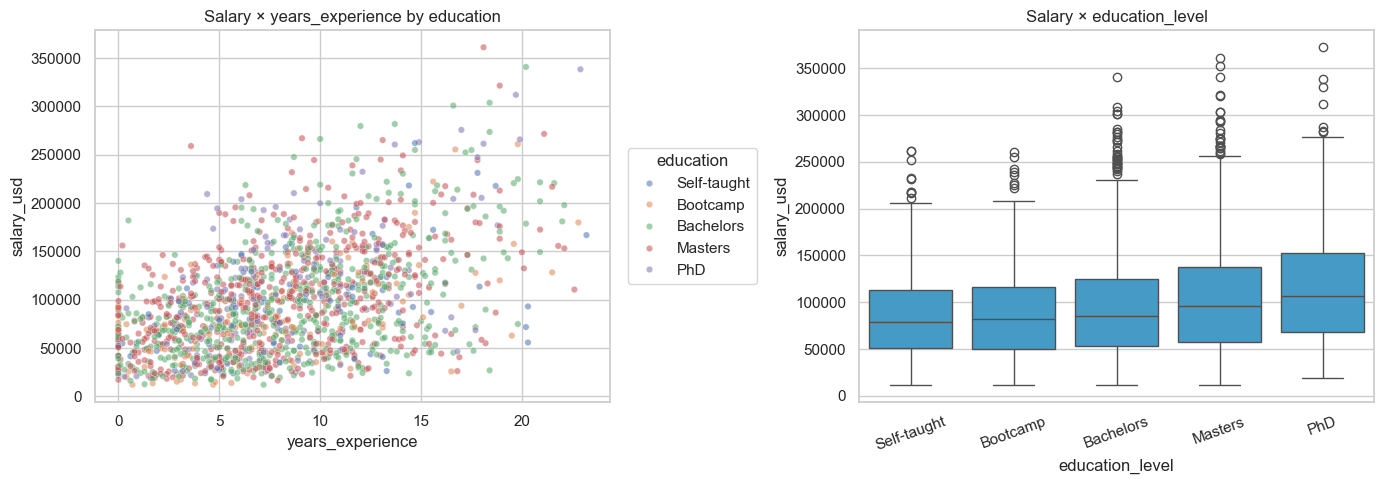

exp_bin,0–3,3–6,6–10,10–15,15+
education_level,,,,,
Self-taught,54931.0,72792.0,85138.0,100996.0,134136.0
Bootcamp,56713.0,71528.0,77112.0,111524.0,129618.0
Bachelors,63152.0,73801.0,89482.0,110544.0,144876.0
Masters,61901.0,85389.0,98828.0,117182.0,166798.0
PhD,73225.0,88369.0,107178.0,136655.0,182625.0


,does_not_manage,manages_people
education_level,,
Self-taught,0.782,0.218
Bootcamp,0.774,0.226
Bachelors,0.770,0.230
Masters,0.775,0.225
PhD,0.761,0.239


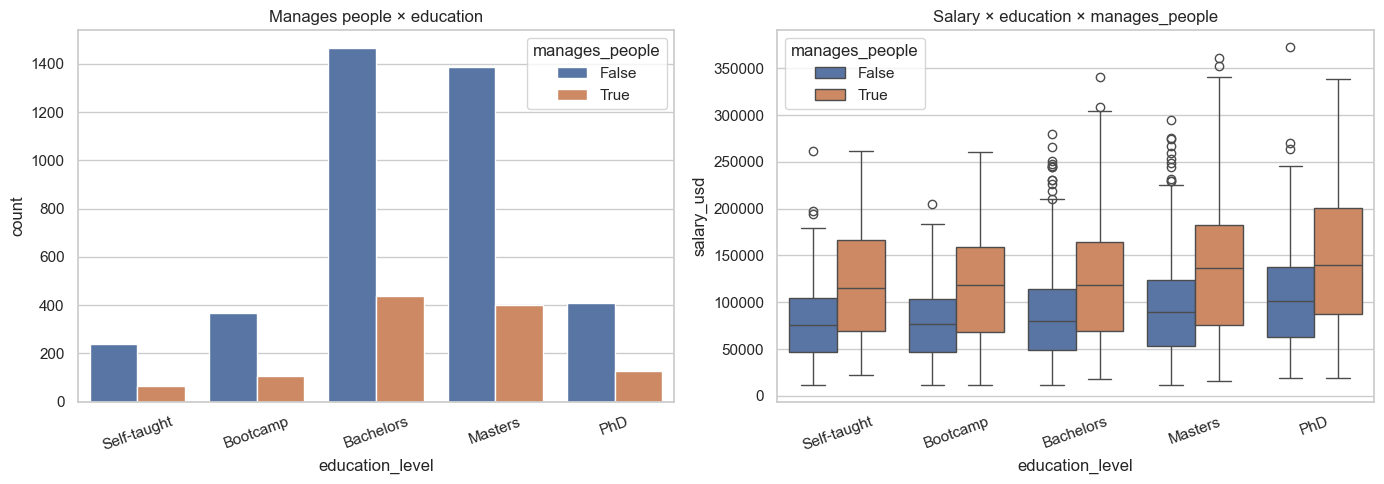

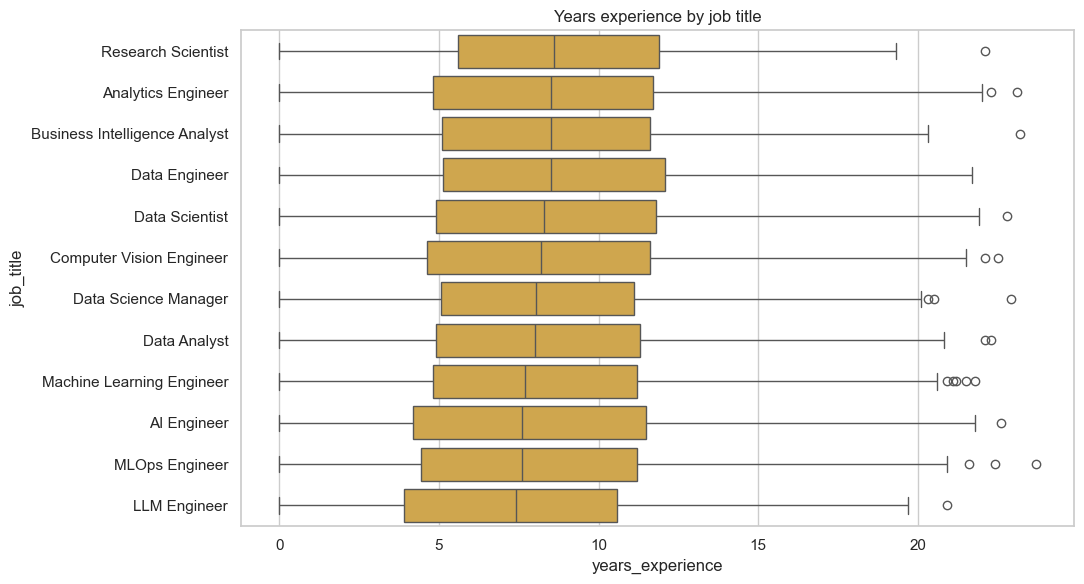

,median,mean,count
job_title,,,
Research Scientist,8.60,8.60,269
Analytics Engineer,8.50,8.53,317
Business Intelligence Analyst,8.50,8.56,293
Data Engineer,8.50,8.67,682
Data Scientist,8.30,8.53,709
Computer Vision Engineer,8.20,8.46,218
Data Science Manager,8.05,8.42,238
Data Analyst,8.00,8.30,627
Machine Learning Engineer,7.70,8.19,593


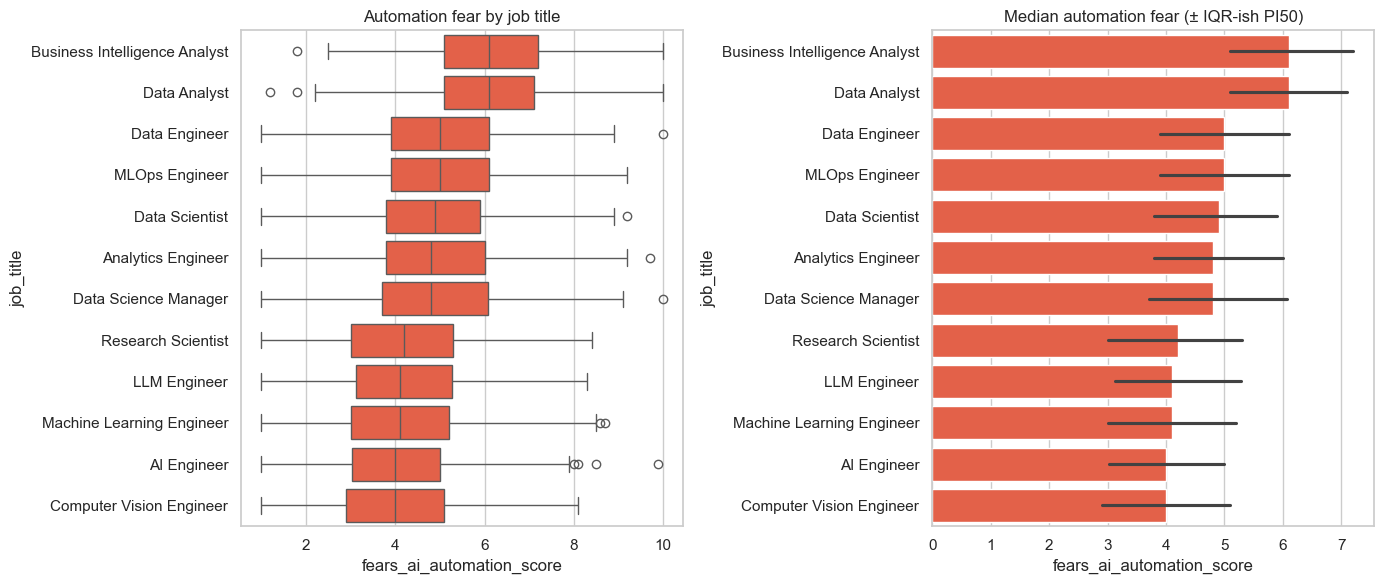

,median,mean,count
job_title,,,
Business Intelligence Analyst,6.1,6.15,293
Data Analyst,6.1,6.13,627
Data Engineer,5.0,4.97,682
MLOps Engineer,5.0,4.97,306
Data Scientist,4.9,4.90,709
Analytics Engineer,4.8,4.94,317
Data Science Manager,4.8,4.86,238
Research Scientist,4.2,4.17,269
LLM Engineer,4.1,4.13,242


In [10]:
# Education ladder used across plots / tables
edu_order = ["Self-taught", "Bootcamp", "Bachelors", "Masters", "PhD"]
edu_order = [e for e in edu_order if e in set(df["education_level"])]

# --- 1) Years experience × education × salary ---
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=df.sample(1500, random_state=7),
    x="years_experience", y="salary_usd",
    hue="education_level", hue_order=edu_order,
    ax=ax[0], alpha=0.55, s=22,
)
ax[0].set_title("Salary × years_experience by education")
ax[0].legend(title="education", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.boxplot(
    data=df, x="education_level", y="salary_usd",
    order=edu_order, ax=ax[1], color="#30a2da",
)
ax[1].set_title("Salary × education_level")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

df["exp_bin"] = pd.cut(
    df["years_experience"],
    bins=[0, 3, 6, 10, 15, 30],
    labels=["0–3", "3–6", "6–10", "10–15", "15+"],
    include_lowest=True,
)
display(
    df.groupby(["education_level", "exp_bin"], observed=True)["salary_usd"]
    .median()
    .unstack()
    .reindex(edu_order)
    .round(0)
)

# --- 2) Education × manages_people ---
mgmt_share = (
    pd.crosstab(df["education_level"], df["manages_people"], normalize="index")
    .reindex(edu_order)
    .round(3)
)
mgmt_share.columns = ["does_not_manage", "manages_people"]
display(mgmt_share)

f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(
    data=df, x="education_level", hue="manages_people",
    order=edu_order, ax=ax[0],
)
ax[0].set_title("Manages people × education")
ax[0].tick_params(axis="x", rotation=20)
sns.boxplot(
    data=df, x="education_level", y="salary_usd",
    hue="manages_people", order=edu_order, ax=ax[1],
)
ax[1].set_title("Salary × education × manages_people")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# --- 3) Experience distribution × job title ---
title_by_exp = (
    df.groupby("job_title")["years_experience"]
    .median()
    .sort_values(ascending=False)
)
f, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df, y="job_title", x="years_experience",
    order=title_by_exp.index, ax=ax, color="#e5ae38",
)
ax.set_title("Years experience by job title")
plt.tight_layout()
plt.show()
display(
    df.groupby("job_title")["years_experience"]
    .agg(["median", "mean", "count"])
    .sort_values("median", ascending=False)
    .round(2)
)

# --- 4) Job title × fear of automation ---
title_by_fear = (
    df.groupby("job_title")["fears_ai_automation_score"]
    .median()
    .sort_values(ascending=False)
)
f, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(
    data=df, y="job_title", x="fears_ai_automation_score",
    order=title_by_fear.index, ax=ax[0], color="#fc4f30",
)
ax[0].set_title("Automation fear by job title")
sns.barplot(
    data=df, y="job_title", x="fears_ai_automation_score",
    order=title_by_fear.index, ax=ax[1], color="#fc4f30",
    estimator="median", errorbar=("pi", 50),
)
ax[1].set_title("Median automation fear (± IQR-ish PI50)")
plt.tight_layout()
plt.show()
display(
    df.groupby("job_title")["fears_ai_automation_score"]
    .agg(["median", "mean", "count"])
    .sort_values("median", ascending=False)
    .round(2)
)


**How to Interpret:** <br>
Median salary by education × experience bin asks whether credentials still separate pay after tenure is held roughly fixed. Management share by education tests whether people-leadership is credential-tied in this generator; salary boxes with `manages_people` hue show any management premium within education. Experience boxes by title flag seniority composition differences before title–pay claims. Fear boxes/bars by title answer who the generator paints as most automation-anxious — often classic analytics roles vs AI/ML builders in this panel.


# **9. Multivariate Association:** <a id="Association"></a>


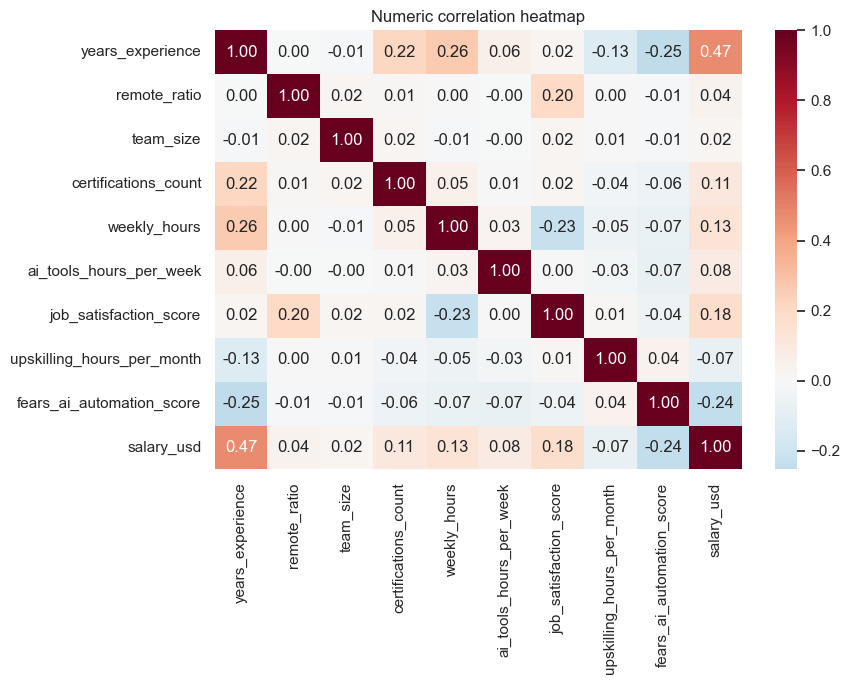

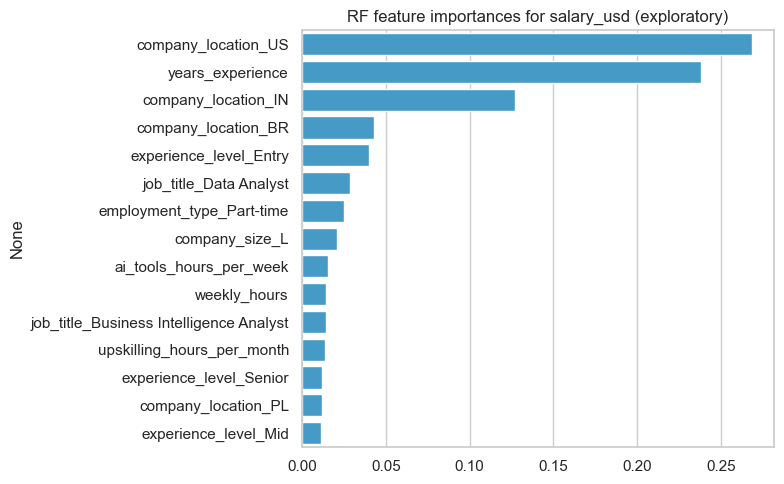

RF in-sample R^2: 0.908


In [11]:
num_cols = [
    "years_experience", "remote_ratio", "team_size", "certifications_count", "weekly_hours",
    "ai_tools_hours_per_week", "job_satisfaction_score", "upskilling_hours_per_month",
    "fears_ai_automation_score", "salary_usd",
]
corr = df[num_cols].corr()
f, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Numeric correlation heatmap")
plt.tight_layout()
plt.show()

# Light RF importances for salary — exclude equity/bonus (compensation leakage)
feature_num = [
    "years_experience", "remote_ratio", "team_size", "certifications_count", "weekly_hours",
    "ai_tools_hours_per_week", "upskilling_hours_per_month", "interviews_to_offer",
]
feature_cat = [
    "experience_level", "job_title", "company_size", "company_location",
    "education_level", "industry", "uses_ai_tools_daily", "employment_type",
]
X = df[feature_num + feature_cat]
y = df["salary_usd"]
pre = ColumnTransformer(
    [
        ("num", "passthrough", feature_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
    ]
)
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=7, n_jobs=-1, max_depth=12)),
])
pipe.fit(X, y)
# importances on transformed space are awkward; use permutation-free RF on encoded matrix
enc = pipe.named_steps["pre"]
rf = pipe.named_steps["rf"]
names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(15)
f, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF feature importances for salary_usd (exploratory)")
plt.tight_layout()
plt.show()
print("RF in-sample R^2:", round(rf.score(enc.transform(X), y), 3))


**How to Interpret:** <br>
Correlations are linear association snapshots. RF importances are exploratory and in-sample — they rank what the tree ensemble used, not causal drivers. Equity/bonus were excluded so the model is not rewarded for predicting pay with other pay pieces.


# **10. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic 2026 AI/DS salary panel with tooling and automation-fear fields built for learning.

**Working takeaways:** <br>
- Seniority and market structure dominate salary; title gaps need experience controls (heatmap in §5).
- `company_location` is a first-order pay axis: US leads, IN/BR sit at the bottom (~0.28× US median). Experience mix is similar across countries, so the gap is not seniority composition.
- After residualizing on years + experience + title, location residuals still span roughly +$33k (US) to −$59k (IN); linear R² jumps from ~0.30 to ~0.72 when location is added.
- Education still separates median pay within experience bins; management rate is roughly flat across credentials (~22–24%).
- Experience distributions by title are close (medians ~7–9 years); fear of automation is higher in BI/Analyst titles than AI/ML builder titles.
- Quote nothing here as a real offer band.

**Open follow-ups:** <br>
- Partial dependence of remote_ratio after experience + location.
- Management premium after controlling for years_experience + title.
- Fear of automation after controlling for title family + AI-tool hours.
